In [6]:
import pandas as pd
import time
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [7]:
# 1. Load Data
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [8]:
# 2. Baseline: No PCA
start = time.time()
clf_full = LogisticRegression()
clf_full.fit(X_train_std, y_train)
end = time.time()

acc_full = accuracy_score(y_test, clf_full.predict(X_test_std))
time_full = end - start

In [9]:
# 3. Apply PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

In [10]:
# 4. Model with PCA
start = time.time()
clf_pca = LogisticRegression()
clf_pca.fit(X_train_pca, y_train)
end = time.time()

acc_pca = accuracy_score(y_test, clf_pca.predict(X_test_pca))
time_pca = end - start

In [11]:
# 5. Results
print(f"Full Features (30) Accuracy: {acc_full:.4f} | Time: {time_full:.6f}s")
print(f"PCA Features (2) Accuracy:   {acc_pca:.4f} | Time: {time_pca:.6f}s")

Full Features (30) Accuracy: 0.9737 | Time: 0.237645s
PCA Features (2) Accuracy:   0.9912 | Time: 0.040377s


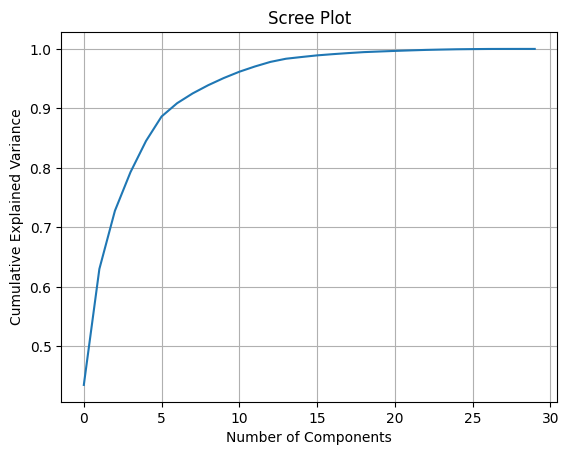

In [12]:
# Visualization: Explained Variance
pca_full = PCA().fit(X_train_std)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.grid()
plt.show()